## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import typing_extensions
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from copy import deepcopy

torch.manual_seed(42)
np.random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [2]:

file_path = "../data/data.csv"
df = pd.read_csv(file_path)

print(df.shape)
df.head()

(944, 10)


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


## 2. Data inspection and preprocessing

In [3]:
print(df.columns.tolist())
print(df.dtypes)
print(df.isna().sum())

['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
footfall       int64
tempMode       int64
AQ             int64
USS            int64
CS             int64
VOC            int64
RP             int64
IP             int64
Temperature    int64
fail           int64
dtype: object
footfall       0
tempMode       0
AQ             0
USS            0
CS             0
VOC            0
RP             0
IP             0
Temperature    0
fail           0
dtype: int64


In [4]:
target_col = "fail"
print(df[target_col].value_counts())

fail
0    551
1    393
Name: count, dtype: int64


In [5]:
df_model = df.copy()

# Drop non-feature columns (optional but may be useful for other dataqsets)
drop_cols = []
for col in df_model.columns:
    if "id" in col.lower():
        drop_cols.append(col)

if drop_cols:
    df_model = df_model.drop(columns=drop_cols)

# Encode binary target if needed
if df_model[target_col].dtype == "object":
    unique_vals = df_model[target_col].unique()
    print("Target values:", unique_vals)
    df_model[target_col] = df_model[target_col].astype("category").cat.codes

df_model.head()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0


In [6]:
print(df_model[target_col].value_counts())

fail
0    551
1    393
Name: count, dtype: int64


In [7]:
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (944, 9)
y shape: (944,)


## 3. Train/test split and sequential batches

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(755, 9) (189, 9)
fail
0    0.584106
1    0.415894
Name: proportion, dtype: float64
fail
0    0.582011
1    0.417989
Name: proportion, dtype: float64


In [9]:
n_batches = 5

X_batches = [batch.copy() for batch in np.array_split(X_train, n_batches)]
y_batches = [batch.copy() for batch in np.array_split(y_train, n_batches)]

for i, (xb, yb) in enumerate(zip(X_batches, y_batches), start=1):
    print(f"Batch {i}: X={xb.shape}, y={yb.shape}")

Batch 1: X=(151, 9), y=(151,)
Batch 2: X=(151, 9), y=(151,)
Batch 3: X=(151, 9), y=(151,)
Batch 4: X=(151, 9), y=(151,)
Batch 5: X=(151, 9), y=(151,)


## 4. Scaling and tensor conversion

In [10]:
scaler = StandardScaler()

X_batch1 = X_batches[0]
scaler.fit(X_batch1)

X_batches_scaled = [scaler.transform(batch) for batch in X_batches]
X_test_scaled = scaler.transform(X_test)

C:\Users\pleri\anaconda3\envs\mlp_poc\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [11]:
X_batches_torch = [
    torch.tensor(batch, dtype=torch.float32)
    for batch in X_batches_scaled
]

y_batches_torch = [
    torch.tensor(batch, dtype=torch.float32).view(-1, 1)
    for batch in y_batches
]

X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_torch = torch.tensor(y_test.to_numpy(), dtype=torch.float32).view(-1, 1)

## 5. MLP baseline

In [12]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

In [13]:
def train_one_batch(model, X_batch, y_batch, epochs=10, lr=0.001, batch_size=32):
    dataset = TensorDataset(X_batch, y_batch)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        for Xb, yb in loader:
            optimizer.zero_grad()
            logits = model(Xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()


def evaluate_model(model, X_eval, y_eval):
    model.eval()
    with torch.no_grad():
        logits = model(X_eval)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()

    y_true = y_eval.cpu().numpy().ravel()
    y_pred = preds.cpu().numpy().ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

## 6. Sequential training results

In [14]:
input_dim = X_train.shape[1]
model = SimpleMLP(input_dim)

history = []

for i, (Xb, yb) in enumerate(zip(X_batches_torch, y_batches_torch), start=1):
    train_one_batch(model, Xb, yb, epochs=10, lr=0.001, batch_size=32)
    metrics = evaluate_model(model, X_test_torch, y_test_torch)
    metrics["batch"] = i
    history.append(metrics)

history_df = pd.DataFrame(history)
history_df

,accuracy,precision,recall,f1,batch
0,0.772487,0.973684,0.468354,0.632479,1
1,0.888889,0.926471,0.797468,0.857143,2
2,0.915344,0.909091,0.886076,0.897436,3
3,0.920635,0.910256,0.898734,0.904459,4
4,0.899471,0.848837,0.924051,0.884848,5


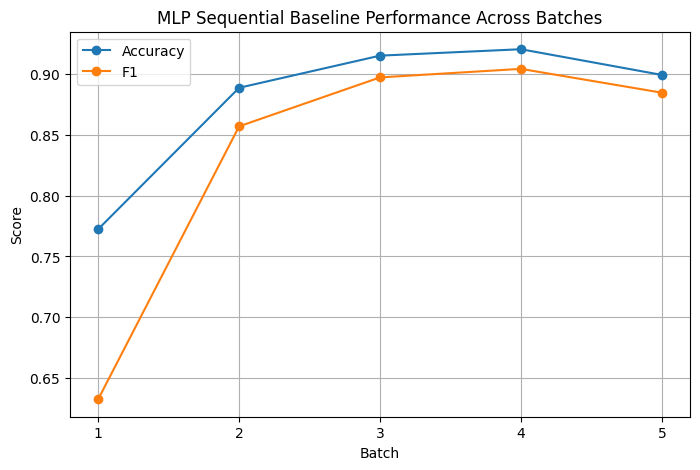

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["batch"], history_df["accuracy"], marker="o", label="Accuracy")
plt.plot(history_df["batch"], history_df["f1"], marker="o", label="F1")
plt.xlabel("Batch")
plt.ylabel("Score")
plt.title("MLP Sequential Baseline Performance Across Batches")
plt.xticks(history_df["batch"])
plt.legend()
plt.grid(True)
plt.show()

## 7. Parameter count and communication-cost proxy

In [16]:
def count_parameters_by_layer(model):
    layer_counts = []
    total = 0

    for name, param in model.named_parameters():
        if param.requires_grad:
            count = param.numel()
            layer_counts.append({"layer": name, "params": count})
            total += count

    return pd.DataFrame(layer_counts), total

param_df, total_params = count_parameters_by_layer(model)
param_df

,layer,params
0,net.0.weight,288
1,net.0.bias,32
2,net.2.weight,512
3,net.2.bias,16
4,net.4.weight,16
5,net.4.bias,1


In [17]:
print("Total trainable parameters:", total_params)

Total trainable parameters: 865


In [18]:
full_transfer_cost = total_params

output_layer_cost = param_df[param_df["layer"].str.contains("4")]["params"].sum()
hidden_layer_cost = total_params - output_layer_cost

print("Full transfer cost:", full_transfer_cost)
print("Hidden-layer-only transfer cost:", hidden_layer_cost)
print("Output-layer-only transfer cost:", output_layer_cost)

Full transfer cost: 865
Hidden-layer-only transfer cost: 848
Output-layer-only transfer cost: 17


## 8. Experiment: full transfer vs partial transfer
### Experiment logic
1. Train a source MLP on batch 1.
2. Create three fresh target MLPs:
   - no transfer
   - output-layer-only transfer
   - full-model transfer
3. Train all three target models on batch 2.
4. Evaluate all three on the same fixed test set.
5. Compare predictive performance against transfer cost.

In [19]:
def copy_full_model_weights(source_model, target_model):
    target_model.load_state_dict(deepcopy(source_model.state_dict()))


def copy_output_layer_only(source_model, target_model):
    source_state = source_model.state_dict()
    target_state = target_model.state_dict()

    # Last Linear layer in Sequential:
    # net.4.weight and net.4.bias
    target_state["net.4.weight"] = deepcopy(source_state["net.4.weight"])
    target_state["net.4.bias"] = deepcopy(source_state["net.4.bias"])

    target_model.load_state_dict(target_state)

In [20]:
input_dim = X_train.shape[1]

source_model = SimpleMLP(input_dim)
train_one_batch(
    source_model,
    X_batches_torch[0],
    y_batches_torch[0],
    epochs=10,
    lr=0.001,
    batch_size=32
)

source_metrics = evaluate_model(source_model, X_test_torch, y_test_torch)
source_metrics

{'accuracy': 0.8835978835978836,
 'precision': 0.9384615384615385,
 'recall': 0.7721518987341772,
 'f1': 0.8472222222222222}

In [21]:
target_no_transfer = SimpleMLP(input_dim)
target_output_only = SimpleMLP(input_dim)
target_full_transfer = SimpleMLP(input_dim)

copy_output_layer_only(source_model, target_output_only)
copy_full_model_weights(source_model, target_full_transfer)

In [22]:
train_one_batch(
    target_no_transfer,
    X_batches_torch[1],
    y_batches_torch[1],
    epochs=10,
    lr=0.001,
    batch_size=32
)

train_one_batch(
    target_output_only,
    X_batches_torch[1],
    y_batches_torch[1],
    epochs=10,
    lr=0.001,
    batch_size=32
)

train_one_batch(
    target_full_transfer,
    X_batches_torch[1],
    y_batches_torch[1],
    epochs=10,
    lr=0.001,
    batch_size=32
)

In [23]:
results = []

no_transfer_metrics = evaluate_model(target_no_transfer, X_test_torch, y_test_torch)
no_transfer_metrics["condition"] = "no_transfer"
no_transfer_metrics["transfer_cost"] = 0
results.append(no_transfer_metrics)

output_only_metrics = evaluate_model(target_output_only, X_test_torch, y_test_torch)
output_only_metrics["condition"] = "output_layer_only"
output_only_metrics["transfer_cost"] = output_layer_cost
results.append(output_only_metrics)

full_transfer_metrics = evaluate_model(target_full_transfer, X_test_torch, y_test_torch)
full_transfer_metrics["condition"] = "full_transfer"
full_transfer_metrics["transfer_cost"] = full_transfer_cost
results.append(full_transfer_metrics)

results_df = pd.DataFrame(results)
results_df = results_df[["condition", "transfer_cost", "accuracy", "precision", "recall", "f1"]]
results_df

,condition,transfer_cost,accuracy,precision,recall,f1
0,no_transfer,0,0.867725,0.837500,0.848101,0.842767
1,output_layer_only,17,0.888889,0.881579,0.848101,0.864516
2,full_transfer,865,0.899471,0.916667,0.835443,0.874172


### Initial observations
- Full transfer provides a reference upper bound for transfer cost.
- Output-layer-only transfer is much cheaper than full transfer.
- The key question is whether the cheaper partial transfer preserves enough predictive performance to be useful.

In [24]:
def run_transfer_experiment_for_pair(
    source_batch_idx,
    target_batch_idx,
    X_batches_torch,
    y_batches_torch,
    X_test_torch,
    y_test_torch,
    input_dim,
    epochs=10,
    lr=0.001,
    batch_size=32
):
    source_model = SimpleMLP(input_dim)
    train_one_batch(
        source_model,
        X_batches_torch[source_batch_idx],
        y_batches_torch[source_batch_idx],
        epochs=epochs,
        lr=lr,
        batch_size=batch_size
    )

    target_no_transfer = SimpleMLP(input_dim)
    target_output_only = SimpleMLP(input_dim)
    target_full_transfer = SimpleMLP(input_dim)

    copy_output_layer_only(source_model, target_output_only)
    copy_full_model_weights(source_model, target_full_transfer)

    train_one_batch(
        target_no_transfer,
        X_batches_torch[target_batch_idx],
        y_batches_torch[target_batch_idx],
        epochs=epochs,
        lr=lr,
        batch_size=batch_size
    )

    train_one_batch(
        target_output_only,
        X_batches_torch[target_batch_idx],
        y_batches_torch[target_batch_idx],
        epochs=epochs,
        lr=lr,
        batch_size=batch_size
    )

    train_one_batch(
        target_full_transfer,
        X_batches_torch[target_batch_idx],
        y_batches_torch[target_batch_idx],
        epochs=epochs,
        lr=lr,
        batch_size=batch_size
    )

    results = []

    no_transfer_metrics = evaluate_model(target_no_transfer, X_test_torch, y_test_torch)
    no_transfer_metrics["condition"] = "no_transfer"
    no_transfer_metrics["transfer_cost"] = 0
    no_transfer_metrics["source_batch"] = source_batch_idx + 1
    no_transfer_metrics["target_batch"] = target_batch_idx + 1
    results.append(no_transfer_metrics)

    output_only_metrics = evaluate_model(target_output_only, X_test_torch, y_test_torch)
    output_only_metrics["condition"] = "output_layer_only"
    output_only_metrics["transfer_cost"] = output_layer_cost
    output_only_metrics["source_batch"] = source_batch_idx + 1
    output_only_metrics["target_batch"] = target_batch_idx + 1
    results.append(output_only_metrics)

    full_transfer_metrics = evaluate_model(target_full_transfer, X_test_torch, y_test_torch)
    full_transfer_metrics["condition"] = "full_transfer"
    full_transfer_metrics["transfer_cost"] = full_transfer_cost
    full_transfer_metrics["source_batch"] = source_batch_idx + 1
    full_transfer_metrics["target_batch"] = target_batch_idx + 1
    results.append(full_transfer_metrics)

    return results

In [25]:
all_results = []

for i in range(len(X_batches_torch) - 1):
    pair_results = run_transfer_experiment_for_pair(
        source_batch_idx=i,
        target_batch_idx=i + 1,
        X_batches_torch=X_batches_torch,
        y_batches_torch=y_batches_torch,
        X_test_torch=X_test_torch,
        y_test_torch=y_test_torch,
        input_dim=input_dim,
        epochs=10,
        lr=0.001,
        batch_size=32
    )
    all_results.extend(pair_results)

all_results_df = pd.DataFrame(all_results)
all_results_df = all_results_df[
    [
        "source_batch",
        "target_batch",
        "condition",
        "transfer_cost",
        "accuracy",
        "precision",
        "recall",
        "f1"
    ]
]

all_results_df

,source_batch,target_batch,condition,transfer_cost,accuracy,precision,recall,f1
0,1,2,no_transfer,0,0.878307,0.924242,0.772152,0.841379
1,1,2,output_layer_only,17,0.846561,0.784091,0.873418,0.826347
2,1,2,full_transfer,865,0.899471,0.865854,0.898734,0.881988
3,2,3,no_transfer,0,0.724868,1.000000,0.341772,0.509434
4,2,3,output_layer_only,17,0.899471,0.968750,0.784810,0.867133
5,2,3,full_transfer,865,0.920635,0.910256,0.898734,0.904459
6,3,4,no_transfer,0,0.910053,0.887500,0.898734,0.893082
7,3,4,output_layer_only,17,0.809524,0.977778,0.556962,0.709677
8,3,4,full_transfer,865,0.894180,0.953846,0.784810,0.861111
9,4,5,no_transfer,0,0.830688,0.979592,0.607595,0.750000


In [26]:
summary_df = (
    all_results_df
    .groupby(["condition", "transfer_cost"], as_index=False)
    .agg(
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean")
    )
    .sort_values("transfer_cost")
)

summary_df

,condition,transfer_cost,mean_accuracy,mean_precision,mean_recall,mean_f1
1,no_transfer,0,0.835979,0.947834,0.655063,0.748474
2,output_layer_only,17,0.847884,0.895890,0.737342,0.798068
0,full_transfer,865,0.903439,0.908840,0.857595,0.880844


In [28]:
all_results_df.sort_values(["source_batch", "condition"])

,source_batch,target_batch,condition,transfer_cost,accuracy,precision,recall,f1
2,1,2,full_transfer,865,0.899471,0.865854,0.898734,0.881988
0,1,2,no_transfer,0,0.878307,0.924242,0.772152,0.841379
1,1,2,output_layer_only,17,0.846561,0.784091,0.873418,0.826347
5,2,3,full_transfer,865,0.920635,0.910256,0.898734,0.904459
3,2,3,no_transfer,0,0.724868,1.000000,0.341772,0.509434
4,2,3,output_layer_only,17,0.899471,0.968750,0.784810,0.867133
8,3,4,full_transfer,865,0.894180,0.953846,0.784810,0.861111
6,3,4,no_transfer,0,0.910053,0.887500,0.898734,0.893082
7,3,4,output_layer_only,17,0.809524,0.977778,0.556962,0.709677
11,4,5,full_transfer,865,0.899471,0.905405,0.848101,0.875817


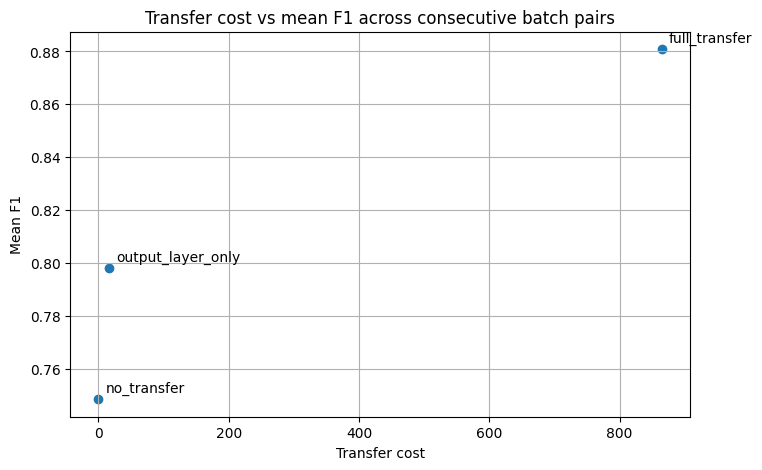

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(summary_df["transfer_cost"], summary_df["mean_f1"])

for _, row in summary_df.iterrows():
    plt.annotate(
        row["condition"],
        (row["transfer_cost"], row["mean_f1"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Transfer cost")
plt.ylabel("Mean F1")
plt.title("Transfer cost vs mean F1 across consecutive batch pairs")
plt.grid(True)
plt.show()

### Interpretation

Across consecutive batch-pair experiments, full transfer achieved the strongest average performance, while output-layer-only transfer improved over no transfer at far lower communication cost.

However, transfer was not uniformly beneficial for every source-target batch pair. In particular, output-layer-only transfer showed unstable behavior on some pairs, likely because the transferred output layer was paired with newly initialized hidden layers rather than the hidden representation it was originally trained with. Full transfer also underperformed no transfer on one batch pair, suggesting that transferred prior knowledge can sometimes be misaligned with the target batch.

Overall, these results support the idea that partial transfer can improve communication efficiency while still preserving some performance benefit, but they also suggest that transfer effectiveness depends on both the selected subnetwork and the similarity between source and target data.

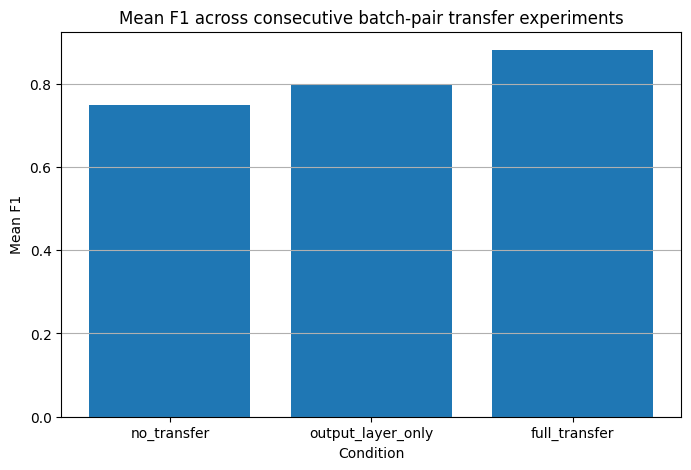

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(summary_df["condition"], summary_df["mean_f1"])
plt.xlabel("Condition")
plt.ylabel("Mean F1")
plt.title("Mean F1 across consecutive batch-pair transfer experiments")
plt.grid(axis="y")
plt.show()

## Next steps

- test additional partial-transfer strategies, such as transferring the last hidden layer together with the output layer
- repeat experiments across multiple random seeds
- investigate whether transfer effectiveness depends on source-target batch similarity